In [5]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np

/home/sagar/Downloads/CL3/.venv/lib/python3.12/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [4]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, (512, 512))
    img = tf.cast(img, tf.float32) / 255.0
    return img[tf.newaxis, :]

content_image = load_image("content.jpg")   # your dog/tiger
style_image = load_image("style.jpg")

NameError: name 'content_image' is not defined

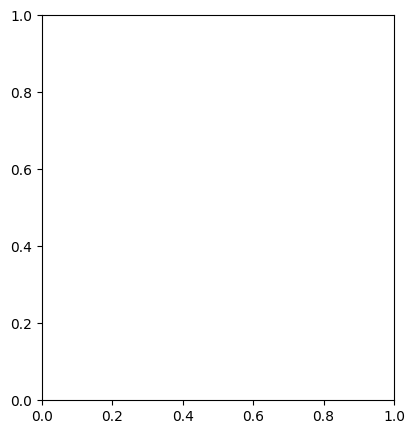

In [7]:
# Display Content and Style Images

plt.figure(figsize=(10,5))

# Content Image
plt.subplot(1,2,1)
plt.imshow(tf.squeeze(content_image))
plt.title("Content Image")
plt.axis('off')

# Style Image
plt.subplot(1,2,2)
plt.imshow(tf.squeeze(style_image))
plt.title("Style Image")
plt.axis('off')

plt.show()

In [5]:
model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')

In [6]:
stylized_image = model(content_image, style_image)[0]

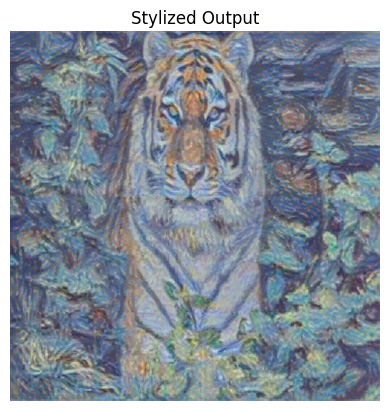

In [7]:
plt.imshow(stylized_image[0])
plt.title("Stylized Output")
plt.axis('off')
plt.show()